In [4]:
from datasets import load_dataset

dataset = load_dataset("dair-ai/emotion")

dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [5]:
from collections import Counter

print("Training distribution:")
print(Counter(dataset["train"]["label"]))

print("\nValidation distribution:")
print(Counter(dataset["validation"]["label"]))

print("\nTest distribution:")
print(Counter(dataset["test"]["label"]))

Training distribution:
Counter({1: 5362, 0: 4666, 3: 2159, 4: 1937, 2: 1304, 5: 572})

Validation distribution:
Counter({1: 704, 0: 550, 3: 275, 4: 212, 2: 178, 5: 81})

Test distribution:
Counter({1: 695, 0: 581, 3: 275, 4: 224, 2: 159, 5: 66})


In [6]:
print(dataset["train"][0])

{'text': 'i didnt feel humiliated', 'label': 0}


In [7]:
print(dataset["train"].features)

{'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}


In [8]:
print(dataset["train"].features["label"])

ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])


In [9]:
print(dataset["train"].features["label"].names)

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [10]:
id2label = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

label2id = {
    "sadness": 0,
    "joy": 1,
    "love": 2,
    "anger": 3,
    "fear": 4,
    "surprise": 5
}

print(id2label)
print(label2id)

{0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
{'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}


In [11]:
from collections import Counter

label_counts = Counter(dataset["train"]["label"])

print(label_counts)

Counter({1: 5362, 0: 4666, 3: 2159, 4: 1937, 2: 1304, 5: 572})


In [12]:
for label_id, count in sorted(label_counts.items()):
    print(f"{id2label[label_id]}: {count}")

sadness: 4666
joy: 5362
love: 1304
anger: 2159
fear: 1937
surprise: 572


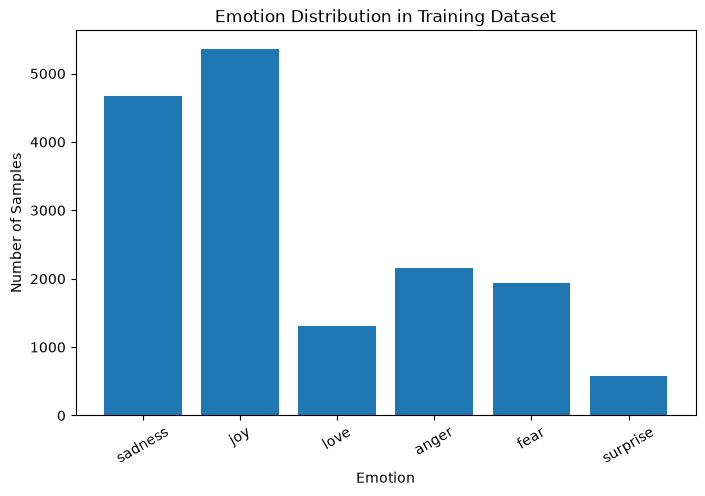

In [13]:
import matplotlib.pyplot as plt

emotions = [id2label[i] for i in sorted(label_counts)]
counts = [label_counts[i] for i in sorted(label_counts)]

plt.figure(figsize=(8, 5))
plt.bar(emotions, counts)

plt.title("Emotion Distribution in Training Dataset")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.xticks(rotation=30)

plt.show()

In [2]:
from transformers import AutoTokenizer

model_checkpoint = "distilbert/distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

print("Tokenizer loaded successfully!")

Tokenizer loaded successfully!


In [14]:
sample_text = dataset["train"][0]["text"]

print("Original text:")
print(sample_text)

print("\nTokens:")
print(tokenizer.tokenize(sample_text))

Original text:
i didnt feel humiliated

Tokens:
['i', 'didn', '##t', 'feel', 'humiliated']


In [15]:
encoded = tokenizer(sample_text)

print(encoded)

{'input_ids': [101, 1045, 2134, 2102, 2514, 26608, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}


In [16]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [17]:
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


In [18]:
print(tokenized_dataset["train"][0])

{'text': 'i didnt feel humiliated', 'label': 0, 'input_ids': [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [19]:
tokenized_dataset = tokenized_dataset.remove_columns(["text"])

print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


In [20]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=6,
    id2label=id2label,
    label2id=label2id
)

print("DistilBERT model loaded successfully!")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1851.30it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model loaded successfully!


In [22]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [21]:
import transformers

print(transformers.__version__)

5.16.1


In [23]:
import inspect
from transformers import TrainingArguments

print(inspect.signature(TrainingArguments))

(output_dir: str | None = None, per_device_train_batch_size: int = 8, num_train_epochs: float = 3.0, max_steps: int = -1, learning_rate: float = 5e-05, lr_scheduler_type: transformers.trainer_utils.SchedulerType | str = 'linear', lr_scheduler_kwargs: dict | str | None = None, warmup_steps: float = 0, optim: transformers.training_args.OptimizerNames | str = 'adamw_torch_fused', optim_args: str | None = None, weight_decay: float = 0.0, adam_beta1: float = 0.9, adam_beta2: float = 0.999, adam_epsilon: float = 1e-08, optim_target_modules: None | str | list[str] = None, gradient_accumulation_steps: int = 1, average_tokens_across_devices: bool = True, max_grad_norm: float = 1.0, label_smoothing_factor: float = 0.0, bf16: bool = False, fp16: bool = False, bf16_full_eval: bool = False, fp16_full_eval: bool = False, tf32: bool | None = None, gradient_checkpointing: bool = False, gradient_checkpointing_kwargs: dict[str, typing.Any] | str | None = None, torch_compile: bool = False, torch_compile_

In [68]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./models/text_emotion_model_fast",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=1,

    weight_decay=0.01,

    eval_strategy="steps",
    eval_steps=100,

    save_strategy="steps",
    save_steps=100,

    report_to="none",

    max_steps=300
)

print("Fast training arguments created!")

Fast training arguments created!


In [26]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics
)

print("Trainer recreated successfully!")

Trainer recreated successfully!


In [41]:
import torch
from transformers import Trainer

# Class weights based on training distribution
class_weights = torch.tensor(
    [
        
        0.5715,  # sadness
        0.4973,  # joy
        2.0450,  # love
        1.2351,  # anger
        1.3767,  # fear
        4.6620   # surprise
    ],
    dtype=torch.float
)

class WeightedTrainer(Trainer):

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):
        labels = inputs.pop("labels")

        outputs = model(**inputs)

        logits = outputs.logits

        loss_function = torch.nn.CrossEntropyLoss(
            weight=class_weights.to(logits.device)
        )

        loss = loss_function(logits, labels)

        return (loss, outputs) if return_outputs else loss


weighted_trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics
)

print("Weighted Trainer created successfully!")

Weighted Trainer created successfully!


In [32]:
weighted_trainer.train()

Step,Training Loss


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.00it/s]


TrainOutput(global_step=100, training_loss=1.618647003173828, metrics={'train_runtime': 808.8996, 'train_samples_per_second': 1.978, 'train_steps_per_second': 0.124, 'total_flos': 52990739251200.0, 'train_loss': 1.618647003173828, 'epoch': 0.1})

In [ ]:
trainer.train()

c:\projects\AI-Mental-Wellbeing-Assistant\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.62it/s]


TrainOutput(global_step=50, training_loss=1.5800689697265624, metrics={'train_runtime': 134.1107, 'train_samples_per_second': 2.983, 'train_steps_per_second': 0.373, 'total_flos': 13247684812800.0, 'train_loss': 1.5800689697265624, 'epoch': 0.025})

In [ ]:
# Save the complete final trained model

final_model_path = "./models/text_emotion_model/final"

trainer.save_model(final_model_path)
tokenizer.save_pretrained(final_model_path)

print("Final model saved successfully!")
print("Training completed at step:", trainer.state.global_step)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.87it/s]

Final model saved successfully!
Training completed at step: 50


In [ ]:
train_result = trainer.state.log_history

for log in train_result:
    print(log)

{'train_runtime': 129.6081, 'train_samples_per_second': 3.086, 'train_steps_per_second': 0.386, 'total_flos': 13247684812800.0, 'train_loss': 1.6747491455078125, 'epoch': 0.025, 'step': 50}


In [ ]:
print(trainer.state.global_step)

50


In [33]:
test_results = trainer.evaluate(
    tokenized_dataset["test"]
)

print(test_results)

c:\projects\AI-Mental-Wellbeing-Assistant\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1
No log,1.344401,0,0.633500,0.594781,0.633500,0.563840


{'eval_loss': 1.3444008827209473, 'eval_accuracy': 0.6335, 'eval_precision': 0.5947806486987531, 'eval_recall': 0.6335, 'eval_f1': 0.5638404235167408}


c:\projects\AI-Mental-Wellbeing-Assistant\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


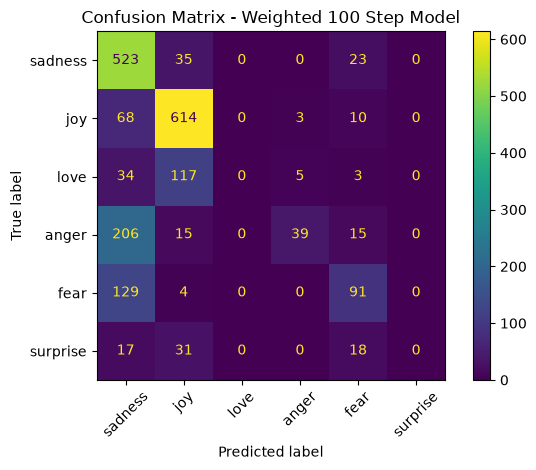

[[523  35   0   0  23   0]
 [ 68 614   0   3  10   0]
 [ 34 117   0   5   3   0]
 [206  15   0  39  15   0]
 [129   4   0   0  91   0]
 [ 17  31   0   0  18   0]]


In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

predictions = weighted_trainer.predict(tokenized_dataset["test"])

predicted_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

cm = confusion_matrix(true_labels, predicted_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[id2label[i] for i in range(6)]
)

disp.plot(
    xticks_rotation=45,
    values_format="d"
)

plt.title("Confusion Matrix - Weighted 100 Step Model")
plt.tight_layout()
plt.show()
print(cm)

In [ ]:
# Save the final trained model
final_model_path = "./models/text_emotion_model/final"

trainer.save_model(final_model_path)
tokenizer.save_pretrained(final_model_path)

print("Final model saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.70it/s]

Final model saved successfully!


In [34]:
import torch

test_texts = [
    "I am extremely happy today.",
    "I love my family so much.",
    "I feel very sad and lonely.",
    "I am scared about my future.",
    "I am extremely angry right now.",
    "Wow! I cannot believe this happened!"
]

for text in test_texts:
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = trainer.model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=-1)
    predicted_id = torch.argmax(probabilities, dim=-1).item()

    print(
        f"{text}\n"
        f"→ {id2label[predicted_id]} "
        f"({probabilities[0][predicted_id].item():.4f})\n"
    )

I am extremely happy today.
→ joy (0.3904)

I love my family so much.
→ joy (0.3629)

I feel very sad and lonely.
→ sadness (0.2938)

I am scared about my future.
→ fear (0.2876)

I am extremely angry right now.
→ sadness (0.2445)

Wow! I cannot believe this happened!
→ joy (0.2556)



In [ ]:
print(training_args)

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_in_order=True,
dataloader_multiprocessing_context=None,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_static_graph=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=False,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_star

In [35]:
import torch

test_texts = [
    # Anger
    "I am so angry right now.",
    "I am furious with him.",
    "This situation makes me really angry.",
    "I hate what happened.",
    "I am extremely frustrated.",
    
    # Fear
    "I am really scared.",
    "I am terrified about tomorrow.",
    "I am afraid something bad will happen.",
    "I feel nervous and frightened.",
    "I am worried about my future.",
    
    # Sadness
    "I feel really sad today.",
    "I am feeling lonely.",
    "I feel heartbroken and miserable.",
    
    # Joy
    "I am extremely happy today.",
    "I feel wonderful and excited.",
    "Today is such a great day."
]

for text in test_texts:
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = weighted_trainer.model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=-1)
    predicted_id = torch.argmax(probabilities, dim=-1).item()

    print(
        f"{text}\n"
        f"→ {id2label[predicted_id]} "
        f"({probabilities[0][predicted_id].item():.4f})\n"
    )

I am so angry right now.
→ anger (0.2501)

I am furious with him.
→ anger (0.2490)

This situation makes me really angry.
→ fear (0.2554)

I hate what happened.
→ anger (0.2512)

I am extremely frustrated.
→ sadness (0.2728)

I am really scared.
→ fear (0.2961)

I am terrified about tomorrow.
→ fear (0.2994)

I am afraid something bad will happen.
→ fear (0.2759)

I feel nervous and frightened.
→ fear (0.3158)

I am worried about my future.
→ fear (0.2741)

I feel really sad today.
→ sadness (0.2961)

I am feeling lonely.
→ sadness (0.2875)

I feel heartbroken and miserable.
→ sadness (0.2953)

I am extremely happy today.
→ joy (0.3904)

I feel wonderful and excited.
→ joy (0.3808)

Today is such a great day.
→ joy (0.3553)



In [40]:
import torch
from collections import Counter

label_counts = Counter(dataset["train"]["label"])

total_samples = sum(label_counts.values())
num_classes = len(label_counts)

class_weights = torch.tensor(
    [
        total_samples / (num_classes * label_counts[i])
        for i in range(num_classes)
    ],
    dtype=torch.float
)

print("Automatic class weights:")
for i, weight in enumerate(class_weights):
    print(f"{id2label[i]}: {weight:.4f}")

Automatic class weights:
sadness: 0.5715
joy: 0.4973
love: 2.0450
anger: 1.2351
fear: 1.3767
surprise: 4.6620


In [43]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=6,
    id2label=id2label,
    label2id=label2id
)

print("Fresh base model loaded successfully!")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1852.25it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh base model loaded successfully!


In [44]:
from transformers import Trainer

weighted_trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics
)

print("Weighted Trainer created with automatic class weights!")

Weighted Trainer created with automatic class weights!


In [45]:
weighted_trainer.train()

c:\projects\AI-Mental-Wellbeing-Assistant\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.10it/s]


TrainOutput(global_step=100, training_loss=1.7814558410644532, metrics={'train_runtime': 516.0479, 'train_samples_per_second': 3.1, 'train_steps_per_second': 0.194, 'total_flos': 52990739251200.0, 'train_loss': 1.7814558410644532, 'epoch': 0.1})

In [46]:
test_results = weighted_trainer.evaluate(tokenized_dataset["test"])
print(test_results)

c:\projects\AI-Mental-Wellbeing-Assistant\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1
No log,1.762972,100,0.157500,0.541843,0.157500,0.126802


{'eval_loss': 1.762972354888916, 'eval_accuracy': 0.1575, 'eval_precision': 0.541843099736297, 'eval_recall': 0.1575, 'eval_f1': 0.12680209074897492}


In [47]:
import torch

class_weights = torch.tensor(
    [
        1.0,   # sadness
        0.8,   # joy
        2.0,   # love
        2.0,   # anger
        2.2,   # fear
        3.5    # surprise
    ],
    dtype=torch.float
)

print("Original weighted class weights restored!")

Original weighted class weights restored!


In [48]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=6,
    id2label=id2label,
    label2id=label2id
)

print("Fresh base model loaded!")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6018.43it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh base model loaded!


In [49]:
from transformers import Trainer

weighted_trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics
)

print("Weighted Trainer recreated successfully!")

Weighted Trainer recreated successfully!


In [50]:
weighted_trainer.train()

c:\projects\AI-Mental-Wellbeing-Assistant\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.80it/s]


TrainOutput(global_step=100, training_loss=1.7252812194824219, metrics={'train_runtime': 514.0281, 'train_samples_per_second': 3.113, 'train_steps_per_second': 0.195, 'total_flos': 52990739251200.0, 'train_loss': 1.7252812194824219, 'epoch': 0.1})

In [51]:
test_results = weighted_trainer.evaluate(tokenized_dataset["test"])
print(test_results)

c:\projects\AI-Mental-Wellbeing-Assistant\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1
No log,1.655895,100,0.482000,0.413899,0.482000,0.393282


{'eval_loss': 1.6558949947357178, 'eval_accuracy': 0.482, 'eval_precision': 0.41389883985875, 'eval_recall': 0.482, 'eval_f1': 0.39328220333995983}


In [52]:
from pathlib import Path

model_path = Path("./models/text_emotion_model_weighted_test")

print("Folder exists:", model_path.exists())

if model_path.exists():
    print("Files/Folders:")
    for item in model_path.iterdir():
        print("-", item.name)

Folder exists: True
Files/Folders:
- checkpoint-100


In [53]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

best_model_path = "./models/text_emotion_model_weighted_test/checkpoint-100"

best_tokenizer = AutoTokenizer.from_pretrained(best_model_path)
best_model = AutoModelForSequenceClassification.from_pretrained(best_model_path)

best_model.eval()

print("Previous 100-step model loaded successfully!")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 7210.64it/s]

Previous 100-step model loaded successfully!


In [54]:
from transformers import Trainer

best_trainer = Trainer(
    model=best_model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    compute_metrics=compute_metrics
)

best_results = best_trainer.evaluate()

print(best_results)

c:\projects\AI-Mental-Wellbeing-Assistant\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1
No log,1.344401,0,0.633500,0.594781,0.633500,0.563840


{'eval_loss': 1.3444008827209473, 'eval_accuracy': 0.6335, 'eval_precision': 0.5947806486987531, 'eval_recall': 0.6335, 'eval_f1': 0.5638404235167408}


In [55]:
from pathlib import Path

final_model_path = Path("./models/text_emotion_model/final")
final_model_path.mkdir(parents=True, exist_ok=True)

best_model.save_pretrained(str(final_model_path))
best_tokenizer.save_pretrained(str(final_model_path))

print("Best model saved successfully!")
print("Path:", final_model_path.resolve())

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.06it/s]

Best model saved successfully!
Path: C:\projects\AI-Mental-Wellbeing-Assistant\notebooks\models\text_emotion_model\final


In [56]:
print("Model label mapping:")
print(best_model.config.id2label)

print("\nTokenizer/model path:")
print(best_model_path)

Model label mapping:
{0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}

Tokenizer/model path:
./models/text_emotion_model_weighted_test/checkpoint-100


In [57]:
test_texts = [
    "I am extremely happy today.",
    "I love my family so much.",
    "I feel very sad and lonely.",
    "I am scared about my future.",
    "I am extremely angry right now.",
    "Wow! I cannot believe this happened!"
]

for text in test_texts:
    inputs = best_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = best_model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=-1)
    predicted_id = torch.argmax(probabilities, dim=-1).item()

    print(
        f"{text}\n"
        f"→ {best_model.config.id2label[predicted_id]} "
        f"({probabilities[0][predicted_id].item():.4f})\n"
    )

I am extremely happy today.
→ love (0.1975)

I love my family so much.
→ love (0.1975)

I feel very sad and lonely.
→ love (0.1975)

I am scared about my future.
→ love (0.1975)

I am extremely angry right now.
→ love (0.1975)

Wow! I cannot believe this happened!
→ love (0.1970)



c:\projects\AI-Mental-Wellbeing-Assistant\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Confusion Matrix:
[[523  35   0   0  23   0]
 [ 68 614   0   3  10   0]
 [ 34 117   0   5   3   0]
 [206  15   0  39  15   0]
 [129   4   0   0  91   0]
 [ 17  31   0   0  18   0]]


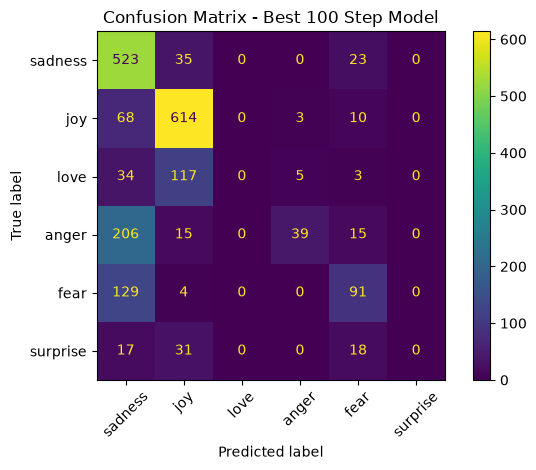

In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

predictions = best_trainer.predict(tokenized_dataset["test"])

predicted_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

cm = confusion_matrix(true_labels, predicted_labels)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[best_model.config.id2label[i] for i in range(6)]
)

disp.plot(
    xticks_rotation=45,
    values_format="d"
)

plt.title("Confusion Matrix - Best 100 Step Model")
plt.tight_layout()
plt.show()
print(cm)


In [59]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

path = "./models/text_emotion_model/final"

tok = AutoTokenizer.from_pretrained(path)
mdl = AutoModelForSequenceClassification.from_pretrained(path)
mdl.eval()

text = "I am extremely happy today."

inputs = tok(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

with torch.no_grad():
    logits = mdl(**inputs).logits

probs = torch.softmax(logits, dim=-1)[0]

print("Final folder predictions:")
for i, p in enumerate(probs):
    print(i, mdl.config.id2label[i], round(p.item(), 4))

print("\nPredicted:", mdl.config.id2label[torch.argmax(probs).item()])

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 6316.63it/s]

Final folder predictions:
0 sadness 0.1663
1 joy 0.1748
2 love 0.1975
3 anger 0.1543
4 fear 0.1865
5 surprise 0.1206

Predicted: love


In [60]:
text = "I am extremely happy today."

inputs = best_tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

with torch.no_grad():
    outputs = best_model(**inputs)

probabilities = torch.softmax(outputs.logits, dim=-1)[0]

for i, p in enumerate(probabilities):
    print(i, best_model.config.id2label[i], round(p.item(), 4))

print("Predicted:", best_model.config.id2label[torch.argmax(probabilities).item()])

0 sadness 0.1663
1 joy 0.1748
2 love 0.1975
3 anger 0.1543
4 fear 0.1865
5 surprise 0.1206
Predicted: love


In [61]:
for i in range(10):
    text = dataset["test"][i]["text"]
    actual = id2label[dataset["test"][i]["label"]]

    inputs = best_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = best_model(**inputs)

    probs = torch.softmax(outputs.logits, dim=-1)
    predicted_id = torch.argmax(probs, dim=-1).item()

    print(
        f"Text: {text}\n"
        f"Actual: {actual} | Predicted: {best_model.config.id2label[predicted_id]}\n"
    )

Text: im feeling rather rotten so im not very ambitious right now
Actual: sadness | Predicted: love

Text: im updating my blog because i feel shitty
Actual: sadness | Predicted: love

Text: i never make her separate from me because i don t ever want her to feel like i m ashamed with her
Actual: sadness | Predicted: love

Text: i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived
Actual: joy | Predicted: love

Text: i was feeling a little vain when i did this one
Actual: sadness | Predicted: love

Text: i cant walk into a shop anywhere where i do not feel uncomfortable
Actual: fear | Predicted: love

Text: i felt anger when at the end of a telephone call
Actual: anger | Predicted: love

Text: i explain why i clung to a relationship with a boy who was in many ways immature and uncommitted despite the excitement i should have been feeling for getting accepted into the masters program at the university of virginia
Actual: joy | P

In [63]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=6,
    id2label=id2label,
    label2id=label2id
)

print("Fresh model loaded successfully!")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6065.08it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh model loaded successfully!


In [64]:
import torch

class_weights = torch.tensor(
    [
        1.0,  # sadness
        1.0,  # joy
        1.5,  # love
        1.2,  # anger
        1.2,  # fear
        1.8   # surprise
    ],
    dtype=torch.float
)

print("Class weights set successfully!")

Class weights set successfully!


In [65]:
from transformers import Trainer

class WeightedTrainer(Trainer):

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):
        labels = inputs.pop("labels")

        outputs = model(**inputs)
        logits = outputs.logits

        loss_function = torch.nn.CrossEntropyLoss(
            weight=class_weights.to(logits.device)
        )

        loss = loss_function(logits, labels)

        return (loss, outputs) if return_outputs else loss


weighted_trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics
)

print("Fresh Weighted Trainer created successfully!")

Fresh Weighted Trainer created successfully!


In [66]:
train_result = weighted_trainer.train()

print("Training completed!")
print(train_result)

c:\projects\AI-Mental-Wellbeing-Assistant\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [67]:
# Check what model is currently loaded
print(model.config.id2label)

test_texts = [
    "I am extremely happy today.",
    "I feel very sad and lonely.",
    "I am extremely angry right now.",
    "I am scared about my future.",
    "I love my family so much.",
    "Wow! I cannot believe this happened!"
]

for text in test_texts:
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=-1)
    predicted_id = torch.argmax(probs, dim=-1).item()

    print(
        f"{text}\n"
        f"→ {model.config.id2label[predicted_id]} "
        f"({probs[0][predicted_id].item():.1%})\n"
    )

{0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
I am extremely happy today.
→ joy (19.0%)

I feel very sad and lonely.
→ joy (19.3%)

I am extremely angry right now.
→ sadness (20.3%)

I am scared about my future.
→ sadness (18.8%)

I love my family so much.
→ sadness (18.1%)

Wow! I cannot believe this happened!
→ joy (18.2%)



In [69]:
weighted_trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics
)

print("Fast Weighted Trainer created successfully!")

Fast Weighted Trainer created successfully!


In [70]:
train_result = weighted_trainer.train()

print("Training completed!")
print(train_result)

Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
100,No log,1.215396,0.585500,0.446139,0.585500,0.464745
200,No log,0.946234,0.723000,0.723718,0.723000,0.669425
300,No log,0.855699,0.742000,0.740897,0.742000,0.692496


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.64it/s]
c:\projects\AI-Mental-Wellbeing-Assistant\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.98it/s]
c:\projects\AI-Mental-Wellbeing-Assistant\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.65it/s]


Training completed!
TrainOutput(global_step=300, training_loss=1.1637370808919272, metrics={'train_runtime': 1874.2766, 'train_samples_per_second': 2.561, 'train_steps_per_second': 0.16, 'total_flos': 158972217753600.0, 'train_loss': 1.1637370808919272, 'epoch': 0.3})


In [71]:
# Evaluate the newly trained model
eval_result = weighted_trainer.evaluate()

print("Evaluation Results:")
print(eval_result)

c:\projects\AI-Mental-Wellbeing-Assistant\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1
No log,0.855699,300,0.742000,0.740897,0.742000,0.692496


Evaluation Results:
{'eval_loss': 0.8556990623474121, 'eval_accuracy': 0.742, 'eval_precision': 0.7408974120646801, 'eval_recall': 0.742, 'eval_f1': 0.6924961226023503}


In [72]:
test_texts = [
    "I am extremely happy today.",
    "I feel very sad and lonely.",
    "I am extremely angry right now.",
    "I am scared about my future.",
    "I love my family so much.",
    "Wow! I cannot believe this happened!"
]

for text in test_texts:
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=-1)
    predicted_id = torch.argmax(probs, dim=-1).item()

    print(
        f"Text: {text}\n"
        f"Prediction: {model.config.id2label[predicted_id]}\n"
        f"Confidence: {probs[0][predicted_id].item():.1%}\n"
    )

Text: I am extremely happy today.
Prediction: joy
Confidence: 76.4%

Text: I feel very sad and lonely.
Prediction: sadness
Confidence: 77.8%

Text: I am extremely angry right now.
Prediction: anger
Confidence: 61.3%

Text: I am scared about my future.
Prediction: fear
Confidence: 64.9%

Text: I love my family so much.
Prediction: joy
Confidence: 61.7%

Text: Wow! I cannot believe this happened!
Prediction: joy
Confidence: 51.4%



In [73]:
import os

final_path = "./models/text_emotion_model_fast/final"

os.makedirs(final_path, exist_ok=True)

model.save_pretrained(final_path)
tokenizer.save_pretrained(final_path)

print("New model saved successfully!")
print(final_path)

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.78it/s]

New model saved successfully!
./models/text_emotion_model_fast/final
